In [1]:
#Arturo Garza - A01198274 - Carrera:IM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('diabetes.csv')

In [2]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
myset = df[['BloodPressure', 'SkinThickness', 'Outcome']]
myset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   BloodPressure  768 non-null    int64
 1   SkinThickness  768 non-null    int64
 2   Outcome        768 non-null    int64
dtypes: int64(3)
memory usage: 18.1 KB


In [4]:
print(myset.describe())


       BloodPressure  SkinThickness     Outcome
count     768.000000     768.000000  768.000000
mean       69.105469      20.536458    0.348958
std        19.355807      15.952218    0.476951
min         0.000000       0.000000    0.000000
25%        62.000000       0.000000    0.000000
50%        72.000000      23.000000    0.000000
75%        80.000000      32.000000    1.000000
max       122.000000      99.000000    1.000000


In [5]:
print(myset.isnull().sum()) 

BloodPressure    0
SkinThickness    0
Outcome          0
dtype: int64


In [6]:
myset.sort_values(by='BloodPressure', ascending=True)

,BloodPressure,SkinThickness,Outcome
15,0,0,1
703,0,0,0
697,0,0,0
78,0,0,1
60,0,0,0
...,...,...,...
177,110,46,1
43,110,24,1
549,110,31,0
691,114,0,1


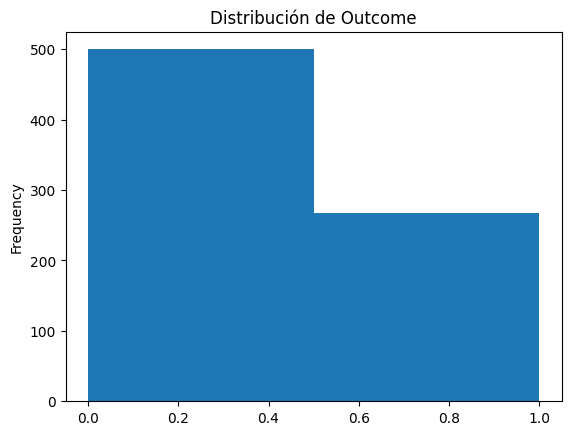

In [60]:
myset['Outcome'].plot(kind='hist', bins=2)
plt.title('Distribución de Outcome')
plt.show()

El total de personas sin diabetes es mayor a las perosnas con diabetes en el dataframe

<Axes: ylabel='Frequency'>

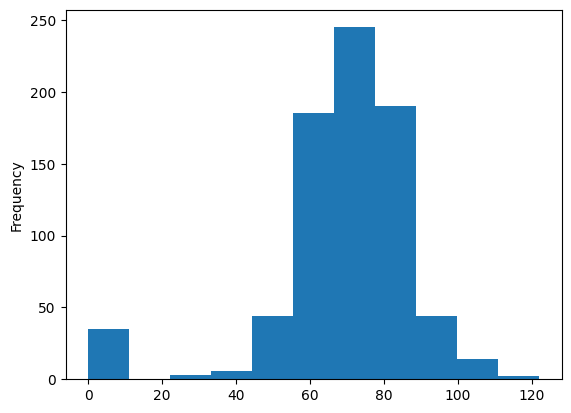

In [8]:
myset['BloodPressure'].plot(kind='hist', bins=11)

La mayoria de las personas tiene presion de sagre de ~70

<Axes: ylabel='Frequency'>

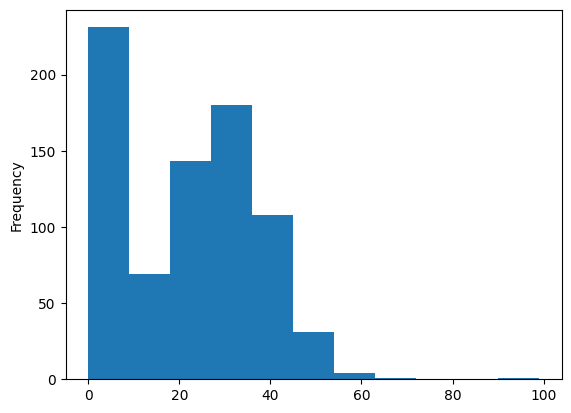

In [9]:
myset['SkinThickness'].plot(kind='hist', bins=11)


La mayoria de las personas tiene grosor de piel de 0 o de ~30 si el 0 es un error

In [18]:
print("Mediana:",myset['BloodPressure'].median())
print("Media:",myset['BloodPressure'].mean())
print(myset['BloodPressure'].dtype)
myset["BloodPressure"].isnull().sum()
mysetBP=myset['BloodPressure'].fillna(myset['BloodPressure'].median())

print("Mediana:",myset['SkinThickness'].median())
print("Media:",myset['SkinThickness'].mean())
print(myset['SkinThickness'].dtype)
myset["SkinThickness"].isnull().sum()
mysetST = myset['SkinThickness'].fillna(myset['SkinThickness'].median())

Mediana: 72.0
Media: 69.10546875
int64
Mediana: 23.0
Media: 20.536458333333332
int64


Text(0.5, 1.0, 'Boxplot de Presion de Sangre')

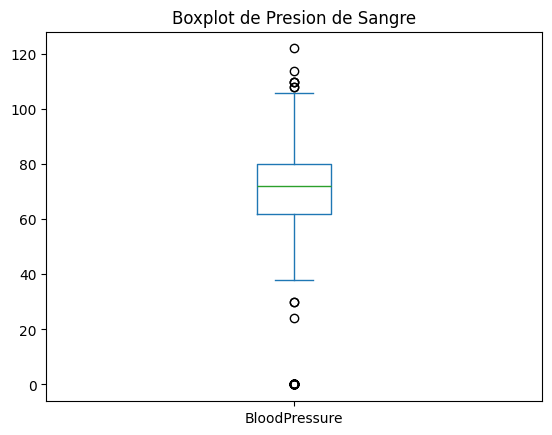

In [19]:
mysetBP.plot(kind='box')
plt.title('Boxplot de Presion de Sangre')

La presion de sangre normal esta en un rango de 60-80

Text(0.5, 1.0, 'Boxplot de Gorsor de Piel')

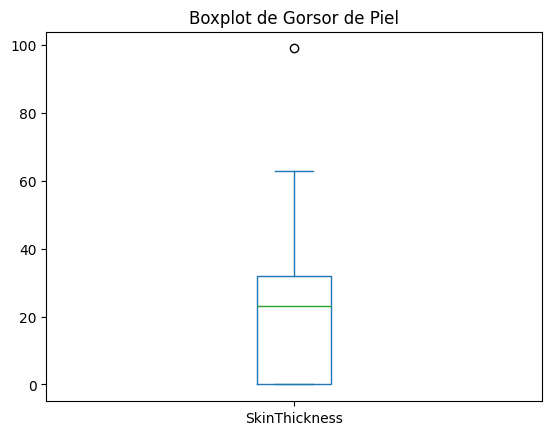

In [20]:
mysetST.plot(kind='box')
plt.title('Boxplot de Gorsor de Piel')

El grosor de piel normal esta en un rango de 0-40

<Axes: >

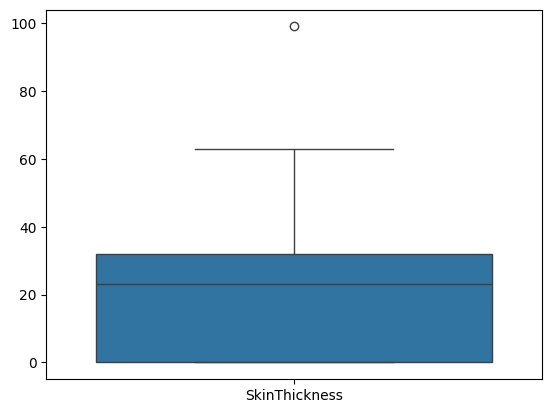

In [21]:
sns.boxplot([mysetST])


<Axes: >

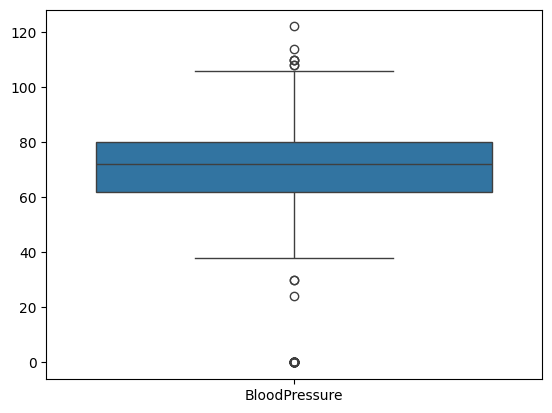

In [22]:
sns.boxplot([mysetBP])

Text(0.5, 1.0, 'Presion de Sangre de acuerdo con Resultado')

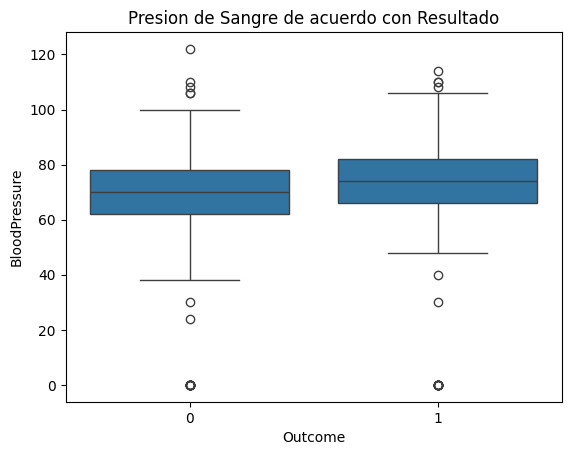

In [54]:
sns.boxplot(myset, x="Outcome", y="BloodPressure")
plt.title("Presion de Sangre de acuerdo con Resultado")

La diferencia de presion de sangre entre los resltados positivos y negativos es negable

Text(0.5, 1.0, 'Edad de acuerdo a sobrevivientes')

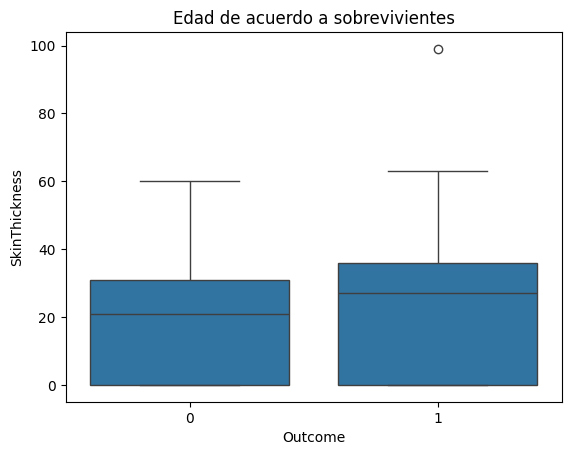

In [53]:
sns.boxplot(myset, x="Outcome", y="SkinThickness")
plt.title("Grosor de Piel de acuerdo con Resultado")

La diferencia de grosor de piel entre los resltados positivos y negativos es negable

Text(0.5, 1.0, 'Presion de Sangre de acuerdo con Resultado')

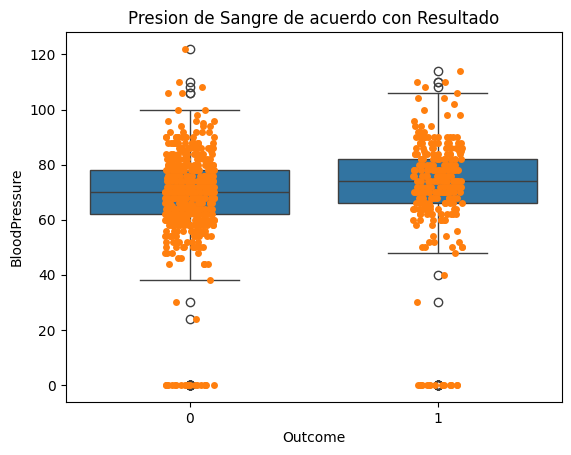

In [56]:
sns.boxplot(myset, x="Outcome", y="BloodPressure")
sns.stripplot(myset, x="Outcome", y="BloodPressure", edgecolor="auto" )
plt.title("Presion de Sangre de acuerdo con Resultado")

Text(0.5, 1.0, 'Grosor de Piel de acuerdo con Resultado')

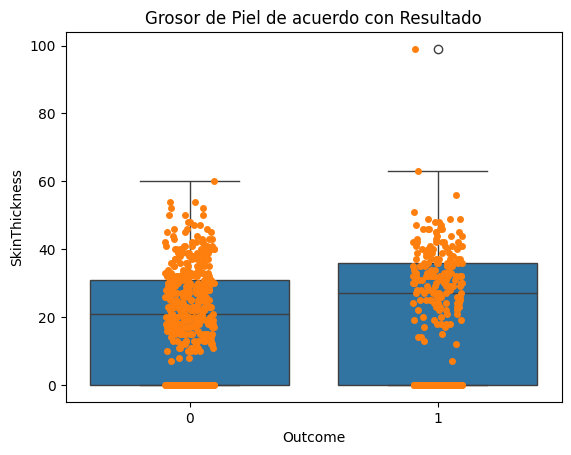

In [57]:
sns.boxplot(myset, x="Outcome", y="SkinThickness")
sns.stripplot(myset, x="Outcome", y="SkinThickness", edgecolor="auto" )
plt.title("Grosor de Piel de acuerdo con Resultado")

Resultados no cambian

In [30]:
correlation_matrix = myset.corr()
correlation_matrix

,BloodPressure,SkinThickness,Outcome
BloodPressure,1.000000,0.207371,0.065068
SkinThickness,0.207371,1.000000,0.074752
Outcome,0.065068,0.074752,1.000000


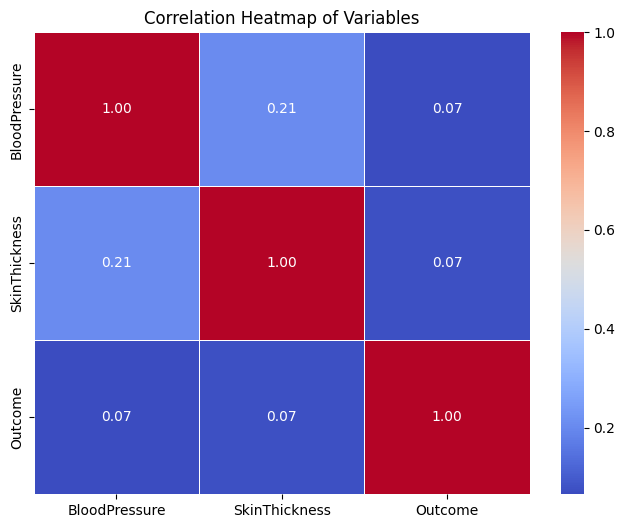

In [31]:

plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix,
        annot=True,      # Show correlation values on the heatmap
        cmap='coolwarm', # Choose a color map (e.g., 'coolwarm', 'RdBu', 'viridis')
        fmt=".2f",       # Format annotation values to two decimal places
        linewidths=.5)   # Add lines between cells
plt.title('Correlation Heatmap of Variables')
plt.show()

Correlacion entre Variables y Resultado es de 0.07 indicando que no afecta de forma significativa

In [32]:
correlation_matrix2 = df.corr()
correlation_matrix2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


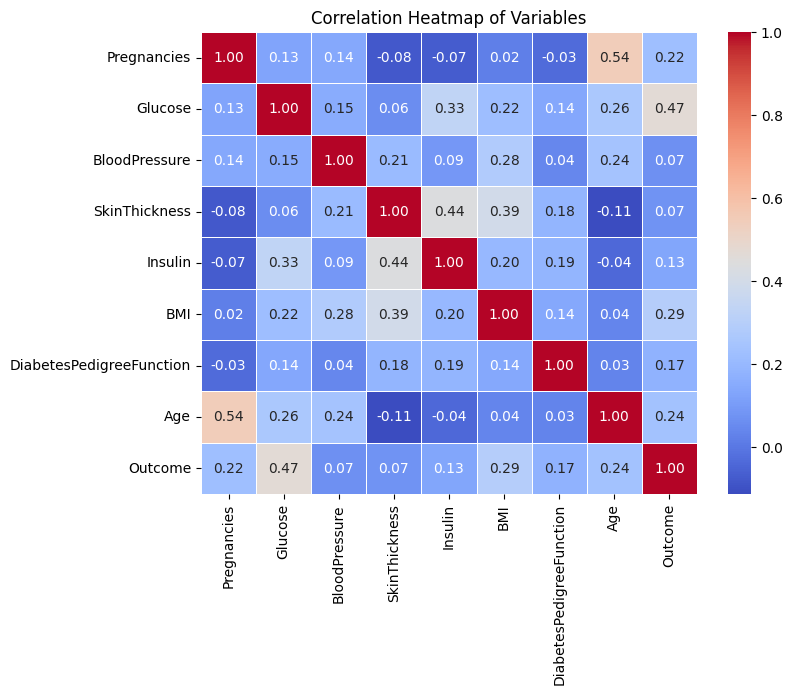

In [33]:

plt.figure(figsize=(8, 6)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix2,
        annot=True,      # Show correlation values on the heatmap
        cmap='coolwarm', # Choose a color map (e.g., 'coolwarm', 'RdBu', 'viridis')
        fmt=".2f",       # Format annotation values to two decimal places
        linewidths=.5)   # Add lines between cells
plt.title('Correlation Heatmap of Variables')
plt.show()

Correlacion de variables BloodPressure y SkinThickness se mantiene igual, variable Glucose muestra relacion significativa con Diabetes 

In [36]:
myset_prep = df.drop(['Pregnancies','Glucose', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age'], axis=1)
myset_prep.head()

,BloodPressure,SkinThickness,Outcome
0,72,35,1
1,66,29,0
2,64,0,1
3,66,23,0
4,40,35,1


In [39]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
myset_prep['BloodPressure'] = label.fit_transform(myset_prep['BloodPressure'])
myset_prep['SkinThickness'] = label.fit_transform(myset_prep['SkinThickness'])

In [40]:
myset_prep.head()

,BloodPressure,SkinThickness,Outcome
0,22,28,1
1,19,22,0
2,17,0,1
3,19,16,0
4,4,28,1


In [41]:
myset_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   BloodPressure  768 non-null    int64
 1   SkinThickness  768 non-null    int64
 2   Outcome        768 non-null    int64
dtypes: int64(3)
memory usage: 18.1 KB


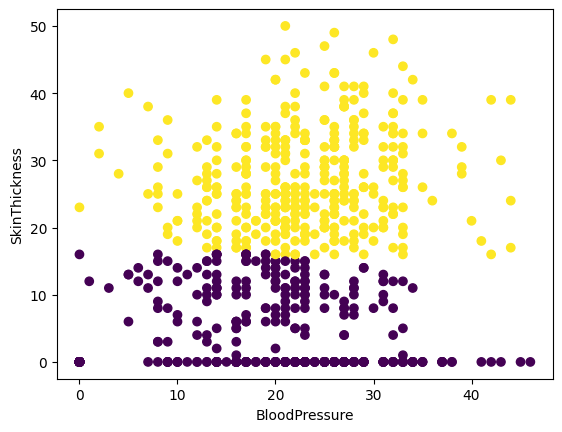

In [43]:
datos1 = myset_prep.loc[:, ['BloodPressure', 'SkinThickness']]
# KMEANS 1
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
kmeans.fit(datos1)
labels = kmeans.predict(datos1)
# visualization
plt.scatter(myset_prep['BloodPressure'], myset_prep['SkinThickness'], c = labels)
plt.xlabel('BloodPressure')
plt.ylabel('SkinThickness')
plt.show()

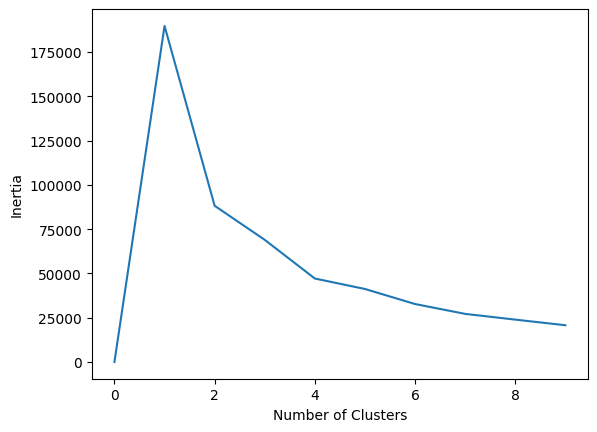

In [45]:
iner_list = np.empty(10)
for i in range(1,10):
    kmeans2 = KMeans(n_clusters=i)
    kmeans2.fit(datos1)
    iner_list[i] = kmeans2.inertia_
# iner_list = iner_list%100
# show the best number in graph
plt.plot(range(0,10), iner_list,'-')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

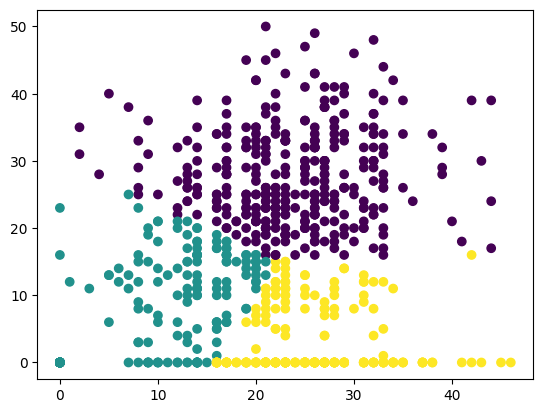

In [48]:
datos1 = myset_prep.loc[:, ['BloodPressure', 'SkinThickness']]
# KMEANS 1
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(datos1)
labels = kmeans.predict(datos1)
# visualization
plt.scatter(myset_prep['BloodPressure'], myset_prep['SkinThickness'], c = labels)

In [49]:
labels = kmeans.labels_
# Ver el número total de etiquetas diferentes (Equivale a Número de clusters encontrados)
num_clusters = np.unique(labels)
print("Etiquetas de clusters:",num_clusters)
print("Total de Registros:",len(kmeans.labels_))
print("Centroides:", kmeans.cluster_centers_)
print("Total de variables que forman parte de un centroide:",len(kmeans.cluster_centers_[0]))

Etiquetas de clusters: [0 1 2]
Total de Registros: 768
Centroides: [[23.62571429 27.74285714]
 [10.80113636  8.76136364]
 [25.45867769  2.80578512]]
Total de variables que forman parte de un centroide: 2


In [ ]:
#############################################################################################################################################

In [ ]:
# No se encontro correlacion entre el Outcome con las variables BloodPressure o SkinThickness, estas variables se pueden romever del dataframe y los resultados
#no se verian afectados de forma significativa
#La variable Glucose muestra una relacion significativa con el resultado de Outcome